<a href="https://colab.research.google.com/github/Vihhycherezass/LungSegmentationUnetPlusPlus/blob/main/LungSegmentationUnetPlusPlus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Подготовка среды и загрузка данных

In [ ]:
!pip install opendatasets albumentations --quiet

##Импорт библиотек

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import opendatasets as od
import albumentations as A
import random
import zipfile

##Загрузка датасета с Kaggle

In [ ]:
dataset_url = "https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/"

od.download(dataset_url)

Skipping, found downloaded files in "./covid19-radiography-database" (use force=True to force download)


##Анализ структуры папок

In [ ]:
os.listdir("./covid19-radiography-database/COVID-19_Radiography_Dataset")

['README.md.txt',
 'Lung_Opacity.metadata.xlsx',
 'COVID',
 'Viral Pneumonia.metadata.xlsx',
 'Lung_Opacity',
 'Normal.metadata.xlsx',
 'Normal',
 'Viral Pneumonia',
 'COVID.metadata.xlsx']

In [ ]:
base_dir = 'covid19-radiography-database/COVID-19_Radiography_Dataset/Normal'

images_dir = os.path.join(base_dir, 'images')
masks_dir = os.path.join(base_dir, 'masks')

In [ ]:
print("Images directory exists:", os.path.exists(images_dir))
print("Masks directory exists:", os.path.exists(masks_dir))

Images directory exists: True
Masks directory exists: True


In [ ]:
# Посмотрим на первые несколько файлов
image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))
print(f"Кол-во изображений: {len(image_files)}")
print(f"Кол-во масок: {len(mask_files)}")
print("Первые пять файлов изображений:", image_files[:5])
print("Первые пять файлов масок:", mask_files[:5])

Кол-во изображений: 10192
Кол-во масок: 10192
Первые пять файлов изображений: ['Normal-1.png', 'Normal-10.png', 'Normal-100.png', 'Normal-1000.png', 'Normal-10000.png']
Первые пять файлов масок: ['Normal-1.png', 'Normal-10.png', 'Normal-100.png', 'Normal-1000.png', 'Normal-10000.png']


In [ ]:
assert image_files[:5] == mask_files[:5], "Имена файлов не совпадают!"
print("Имена файлов совпадают.")

Имена файлов совпадают.


##Исследовательский анализ данных (EDA)

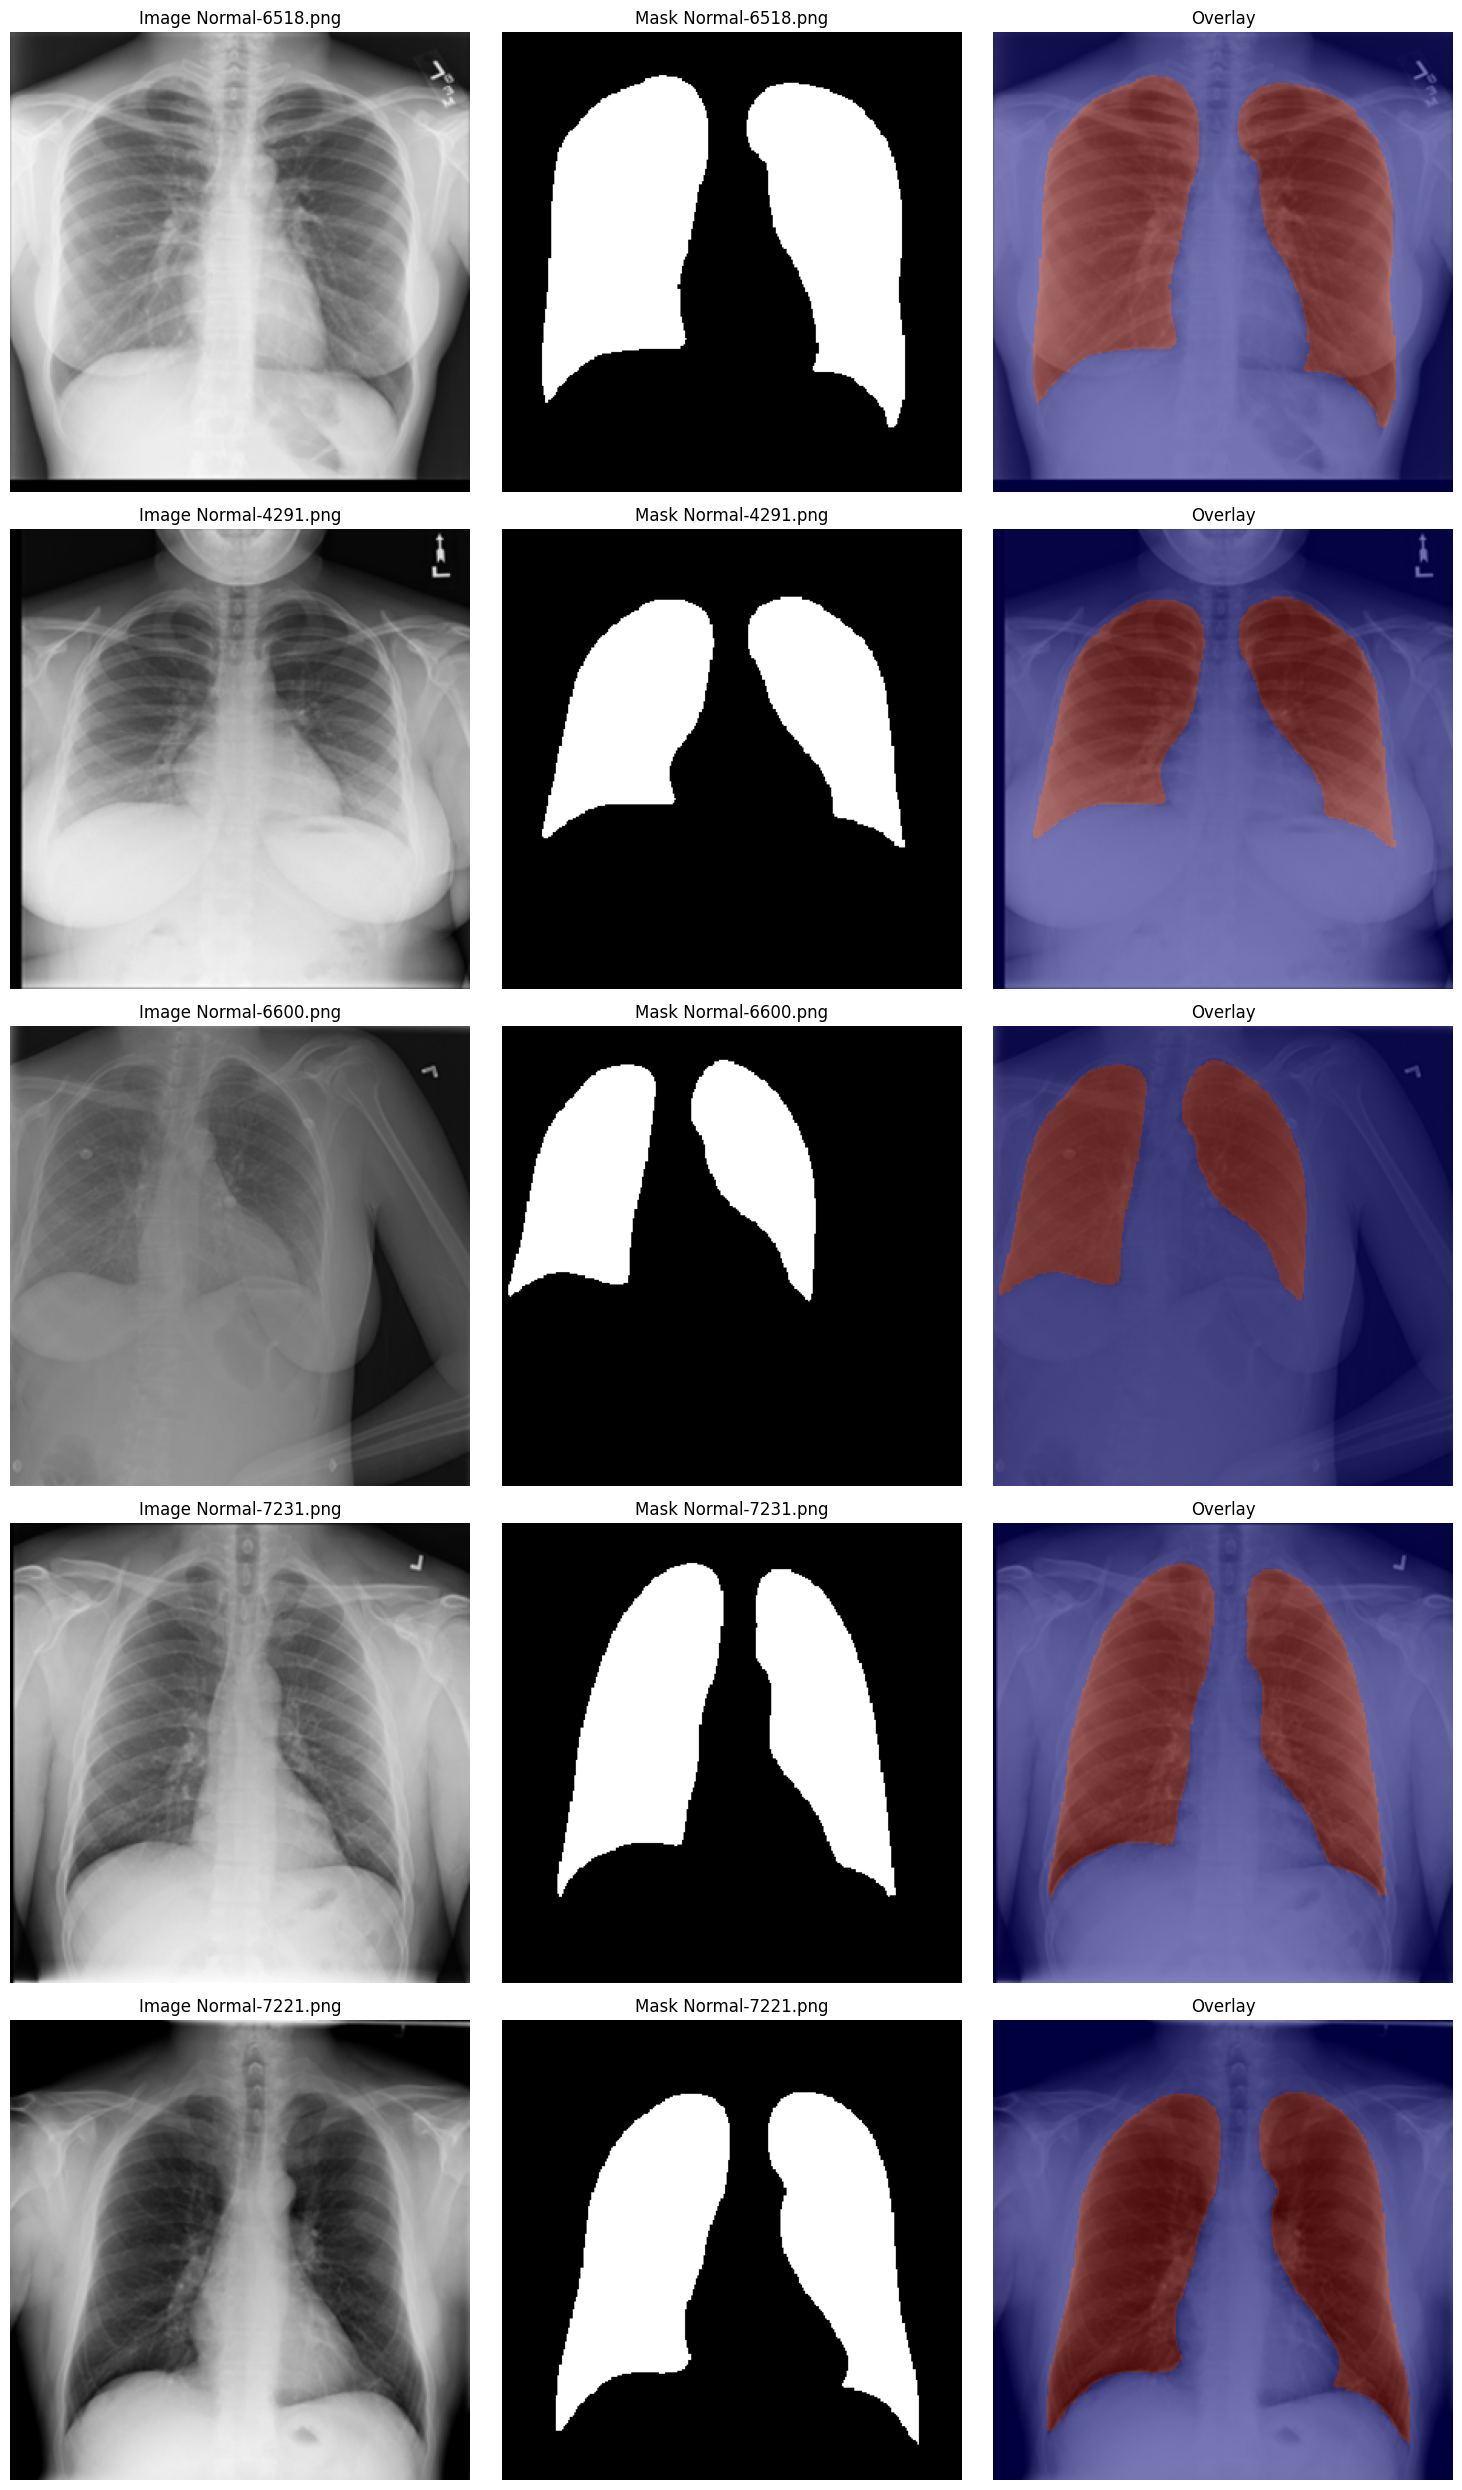

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

num_samples = 5
random_indices = random.sample(range(len(image_files)), num_samples)

plt.figure(figsize=(15, num_samples * 5))
for i, idx in enumerate(random_indices):
    # Загружаем изображение и маску
    img_path = os.path.join(images_dir, image_files[idx])
    mask_path = os.path.join(masks_dir, mask_files[idx])

    # Загружаем изображение в RGB, маску в grayscale
    img = load_img(img_path, target_size=(299, 299), color_mode='rgb')
    mask = load_img(mask_path, target_size=(299, 299), color_mode='grayscale')

    # Преобразуем в массивы numpy
    img_array = img_to_array(img).astype(np.uint8)
    mask_array = img_to_array(mask).astype(np.uint8)  # форма (299,299,1)

    # Визуализируем
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(img_array)
    plt.title(f'Image {image_files[idx]}')
    plt.axis('off')

    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(mask_array[:,:,0], cmap='gray')
    plt.title(f'Mask {mask_files[idx]}')
    plt.axis('off')

    # Наложение маски на изображение (для наглядности)
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(img_array)
    plt.imshow(mask_array[:,:,0], cmap='jet', alpha=0.5)  # цветная маска поверх
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()


##Проверим уникальные значения в маске (должны быть 0 и 255 или 0 и 1)

In [ ]:
print("Уникальные значения в маске на первом примере:", np.unique(mask_array))

mask_values = []
for i in range(min(20, len(mask_files))):
    mask_path = os.path.join(masks_dir, mask_files[i])
    mask = load_img(mask_path, target_size=(256,256), color_mode='grayscale')
    mask_array = img_to_array(mask)
    mask_values.extend(mask_array.flatten())

unique, counts = np.unique(mask_values, return_counts=True)
print("Уникальные значения по 20 маскам:", dict(zip(unique, counts)))

Уникальные значения в маске на первом примере: [  0 255]
Уникальные значения по 20 маскам: {np.float32(0.0): np.int64(978086), np.float32(255.0): np.int64(332634)}


##Оценим площадь легких (доля пикселей класса 255) для понимания дисбаланса.

In [ ]:
total_pixels = len(mask_values)
lung_pixels = counts[unique == 255][0] if 255 in unique else 0
lung_fraction = lung_pixels / total_pixels
print(f"Доля пикселей легких (класс 255) в выборке: {lung_fraction:.4f}")
print(f"Это означает, что легкие занимают примерно {lung_fraction*100:.2f}% изображения.")

Доля пикселей легких (класс 255) в выборке: 0.2538
Это означает, что легкие занимают примерно 25.38% изображения.


##Подготовка данных: разделение на train/val и создание генератора

## Формирование списков путей

In [ ]:
from tensorflow.keras.utils import to_categorical

image_paths = sorted([os.path.join(images_dir, fname) for fname in image_files])
mask_paths = sorted([os.path.join(masks_dir, fname) for fname in mask_files])

# Перемешаем списки синхронно
combined = list(zip(image_paths, mask_paths))
random.shuffle(combined)
image_paths[:], mask_paths[:] = zip(*combined)

##Разделение 80/20

In [ ]:
split_idx = int(0.8 * len(image_paths))
train_images = image_paths[:split_idx]
train_masks = mask_paths[:split_idx]
val_images = image_paths[split_idx:]
val_masks = mask_paths[split_idx:]

print(f"Размер обучающей выборки: {len(train_images)}")
print(f"Размер валидационной выборки: {len(val_images)}")

Размер обучающей выборки: 8153
Размер валидационной выборки: 2039


##Класс генератора

In [ ]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 64

class DataGenerator(keras.utils.Sequence):
  def __init__(self, image_paths, mask_paths, batch_size, img_size, augment=False):
    super().__init__()
    self.image_paths = image_paths
    self.mask_paths = mask_paths
    self.batch_size = batch_size
    self.img_size = img_size
    self.augment = augment

    if augment:
      self.transform = A.Compose([
          A.HorizontalFlip(p=0.5),
          A.RandomRotate90(p=0.5),
          A.ShiftScaleRotate(
              shift_limit = 0.1,
              scale_limit = 0.2,
              rotate_limit = 30,
              p = 0.5,
              border_mode = 0,
              mask_interpolation=0
          ),
          A.RandomResizedCrop(
              size=img_size,
              scale=(0.8, 1.0),
              ratio=(0.9, 1.1),
              p=0.5,
              interpolation=1,
              mask_interpolation=0
          )
      ])
    else:
      self.transform = None

  def __len__(self):
    return len(self.image_paths) // self.batch_size

  def __getitem__(self, idx):
    batch_img_paths = self.image_paths[idx * self.batch_size: (idx + 1) * self.batch_size]
    batch_mask_paths = self.mask_paths[idx * self.batch_size: (idx + 1) * self.batch_size]

    X = np.zeros((self.batch_size, *self.img_size, 3), dtype=np.float32)
    Y = np.zeros((self.batch_size, *self.img_size, 1), dtype=np.float32)

    for i, (img_path, mask_path) in enumerate(zip(batch_img_paths, batch_mask_paths)):
      img = load_img(img_path, target_size=self.img_size, color_mode="rgb")
      img = img_to_array(img)

      mask = load_img(mask_path, target_size=self.img_size, color_mode="grayscale")
      mask = img_to_array(mask)

      mask = mask / 255.0

      if self.transform:
        augmented = self.transform(image=img.astype(np.uint8), mask=mask.astype(np.float32))
        img = augmented["image"]
        mask = augmented["mask"]
        mask = (mask > 0.5).astype(np.float32)

      img = img / 255.0

      if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)

      X[i] = img
      Y[i] = np.round(mask)

    return X, Y

##Создаём генераторы

In [ ]:
train_gen = DataGenerator(train_images, train_masks, BATCH_SIZE, IMG_SIZE, augment=False)
val_gen = DataGenerator(val_images, val_masks, BATCH_SIZE, IMG_SIZE, augment=False)

x_batch, y_batch = train_gen[0]

print("x_batch shape:", x_batch.shape)  # (batch, 256, 256, 3)
print("y_batch shape:", y_batch.shape)  # (batch, 256, 256, 1)
print("x_batch min/max:", x_batch.min(), x_batch.max())
print("y_batch min/max:", y_batch.min(), y_batch.max())

x_batch shape: (64, 256, 256, 3)
y_batch shape: (64, 256, 256, 1)
x_batch min/max: 0.0 1.0
y_batch min/max: 0.0 1.0


У нас получилось сделать рабочий генератор!

In [ ]:
def gen_train():
    for x, y in train_gen:
        yield x, y

def gen_val():
    for x, y in val_gen:
        yield x, y

train_dataset = tf.data.Dataset.from_generator(
    gen_train,
    output_signature=(
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *IMG_SIZE, 1), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    gen_val,
    output_signature=(
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *IMG_SIZE, 1), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

##Визуализируем один пример из батча

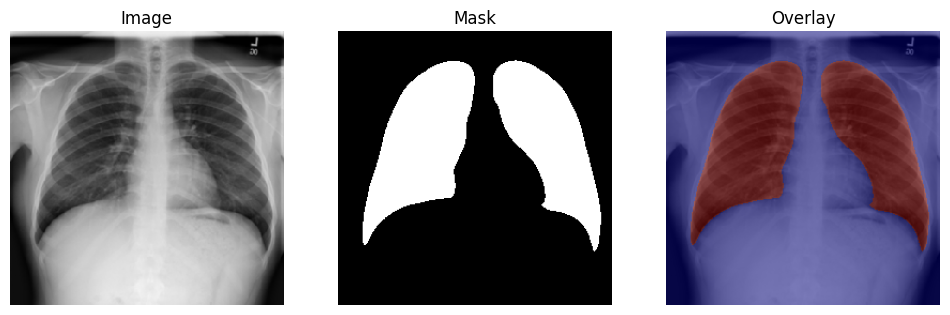

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x_batch[0])
plt.title('Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(y_batch[0,:,:,0], cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(x_batch[0])
plt.imshow(y_batch[0,:,:,0], cmap='jet', alpha=0.5)
plt.title('Overlay')
plt.axis('off')
plt.show()

##Реализация архитектуры U-Net++ (Мы построим U-Net++  с глубиной 4 (5 уровней, включая входной))

Encoder – стандартные блоки свёртки (Conv2D + BatchNormalization + ReLU) с MaxPooling для уменьшения размера.

Плотные соединения – на каждом уровне декодера мы будем объединять все предыдущие выходы этого же уровня (с меньшей глубиной) и апсемпленный выход с более глубокого уровня.

Выход – слой свёртки 1x1 с 1 фильтром и активацией sigmoid (для бинарной сегментации).

##Вспомогательные функции

In [ ]:
from tensorflow.keras import Model

def conv_block(x, filters, kernel_size=3, activation="relu"):
  x = layers.Conv2D(filters, kernel_size, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation(activation)(x)

  x = layers.Conv2D(filters, kernel_size, padding="same", kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation(activation)(x)

  return x

##Построение U-Net++

Создаем архитекруту U-Net++ по данному примеру:
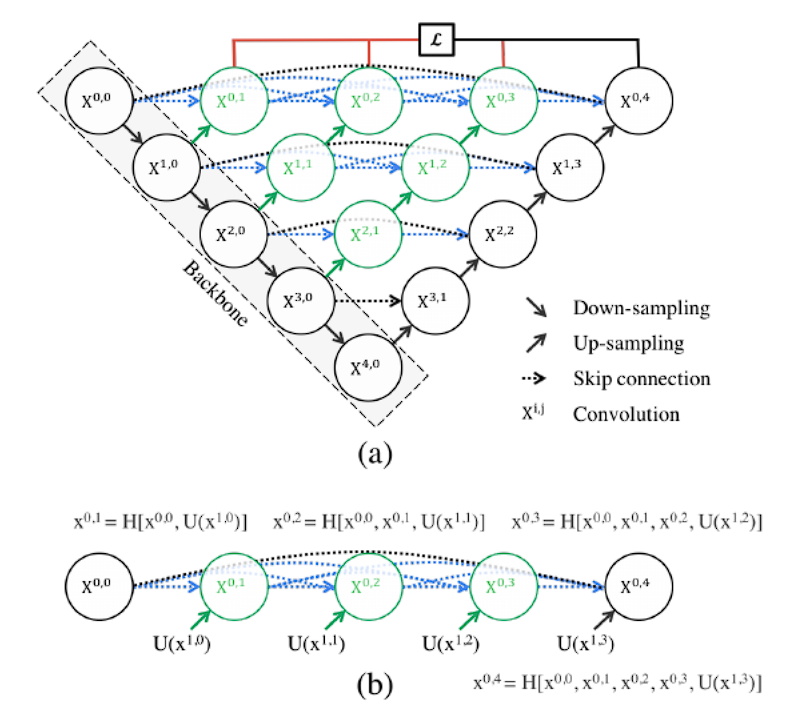

In [ ]:
def build_unet_plus_plus(input_shape=(256, 256, 3), num_filters=32, num_classes=1):
  inputs = layers.Input(shape=input_shape)

  # Список списков для хранения узлов X[i][j]
  X = [[None for j in range(5 - i)] for i in range(5)] # i=0..4, j=0..4-i

  X[0][0] = inputs
  for i in range(1, 5):
    pool = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(X[i - 1][0])
    X[i][0] = conv_block(pool, num_filters * (2 ** (i - 1)))

  for j in range(1,5):
    for i in range(0, 5 - j):
      skip_connections = [X[i][k] for k in range(j)]

      if i + 1 < len(X) and j - 1 < len(X[i + 1]) and X[i + 1][j - 1] is not None:
        filters = num_filters * (2**i)
        upsample = layers.Conv2DTranspose(filters=filters, kernel_size=(2, 2), strides=(2, 2), padding="same")(X[i + 1][j - 1])
        skip_connections.append(upsample)

      concat = layers.Concatenate()(skip_connections)


      X[i][j] = conv_block(concat, filters)

  output = layers.Conv2D(num_classes, kernel_size=1, padding="same")(X[0][4])

  model = Model(inputs, output)
  return model

##Проверка архитектуры

In [ ]:
input_shape = (*IMG_SIZE, 3)
model = build_unet_plus_plus(input_shape=input_shape, num_filters=32, num_classes=1)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (MaxPooling2D)      │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[

 Total params: 4,633,473 (17.68 MB)

 Trainable params: 4,628,225 (17.66 MB)

 Non-trainable params: 5,248 (20.50 KB)

##Проверка генератора

In [ ]:
for x_batch, y_batch in train_gen:
    print("x shape:", x_batch.shape, "min/max:", x_batch.min(), x_batch.max())
    print("y shape:", y_batch.shape, "min/max:", y_batch.min(), y_batch.max())
    break

x shape: (64, 256, 256, 3) min/max: 0.0 1.0
y shape: (64, 256, 256, 1) min/max: 0.0 1.0


##Компиляция модели

Так же я решил попробовать использовать метрику MeanLoU

In [ ]:
class NanCallback(keras.callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        for w in self.model.trainable_weights:
            if tf.reduce_any(tf.math.is_nan(w)):
                print(f"NaN detected in {w.name} at batch {batch}")
                self.model.stop_training = True
                return

class ValidPredLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 2 == 0:  # каждые 2 эпохи
            x_sample, _ = next(iter(val_dataset.take(1)))
            pred = self.model.predict(x_sample, verbose=0)
            print(f"Epoch {epoch+1} pred stats: min={pred.min():.4f}, max={pred.max():.4f}, mean={pred.mean():.4f}, std={pred.std():.4f}")

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=5e-5, clipvalue=0.5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy', MeanIoU(num_classes=2)] #num_classes=2, потому что у нас фон и легкие
)

checkpoint = ModelCheckpoint(
    'best_unetplusplus.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir='./logs',
    histogram_freq=1,
    update_freq='batch'
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    callbacks=[checkpoint, early_stop, reduce_lr, NanCallback(), ValidPredLogger(), tensorboard_cb],
    verbose=1
)

Epoch 1/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8290 - loss: 0.5068 - mean_io_u_1: 0.4624
Epoch 1: val_loss improved from inf to 0.67506, saving model to best_unetplusplus.keras

🔍 Epoch 1 pred stats: min=-0.9819, max=2.1095, mean=0.1577, std=0.5487
127/127 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.8296 - loss: 0.5056 - mean_io_u_1: 0.4628 - val_accuracy: 0.7778 - val_loss: 0.6751 - val_mean_io_u_1: 0.4474 - learning_rate: 5.0000e-05
Epoch 2/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9313 - loss: 0.5583 - mean_io_u_1: 0.4859
Epoch 2: val_loss did not improve from 0.67506
127/127 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9317 - loss: 0.5570 - mean_io_u_1: 0.4860 - val_accuracy: 0.7362 - val_loss: 0.7706 - val_mean_io_u_1: 0.3653 - learning_rate: 5.0000e-05
Epoch 3/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.2557 - mean_io_u_1: 0.5000
Epoch 3: val_loss did not improve from 0.67506

Epoch 3: ReduceLROnPlateau reducing 

##Отслеживание прогресса

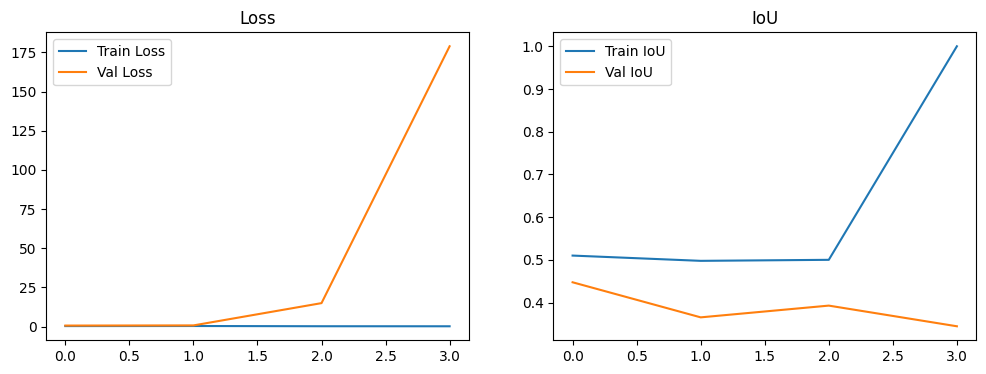

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_io_u_1'], label='Train IoU')
plt.plot(history.history['val_mean_io_u_1'], label='Val IoU')
plt.title('IoU')
plt.legend()

plt.show()

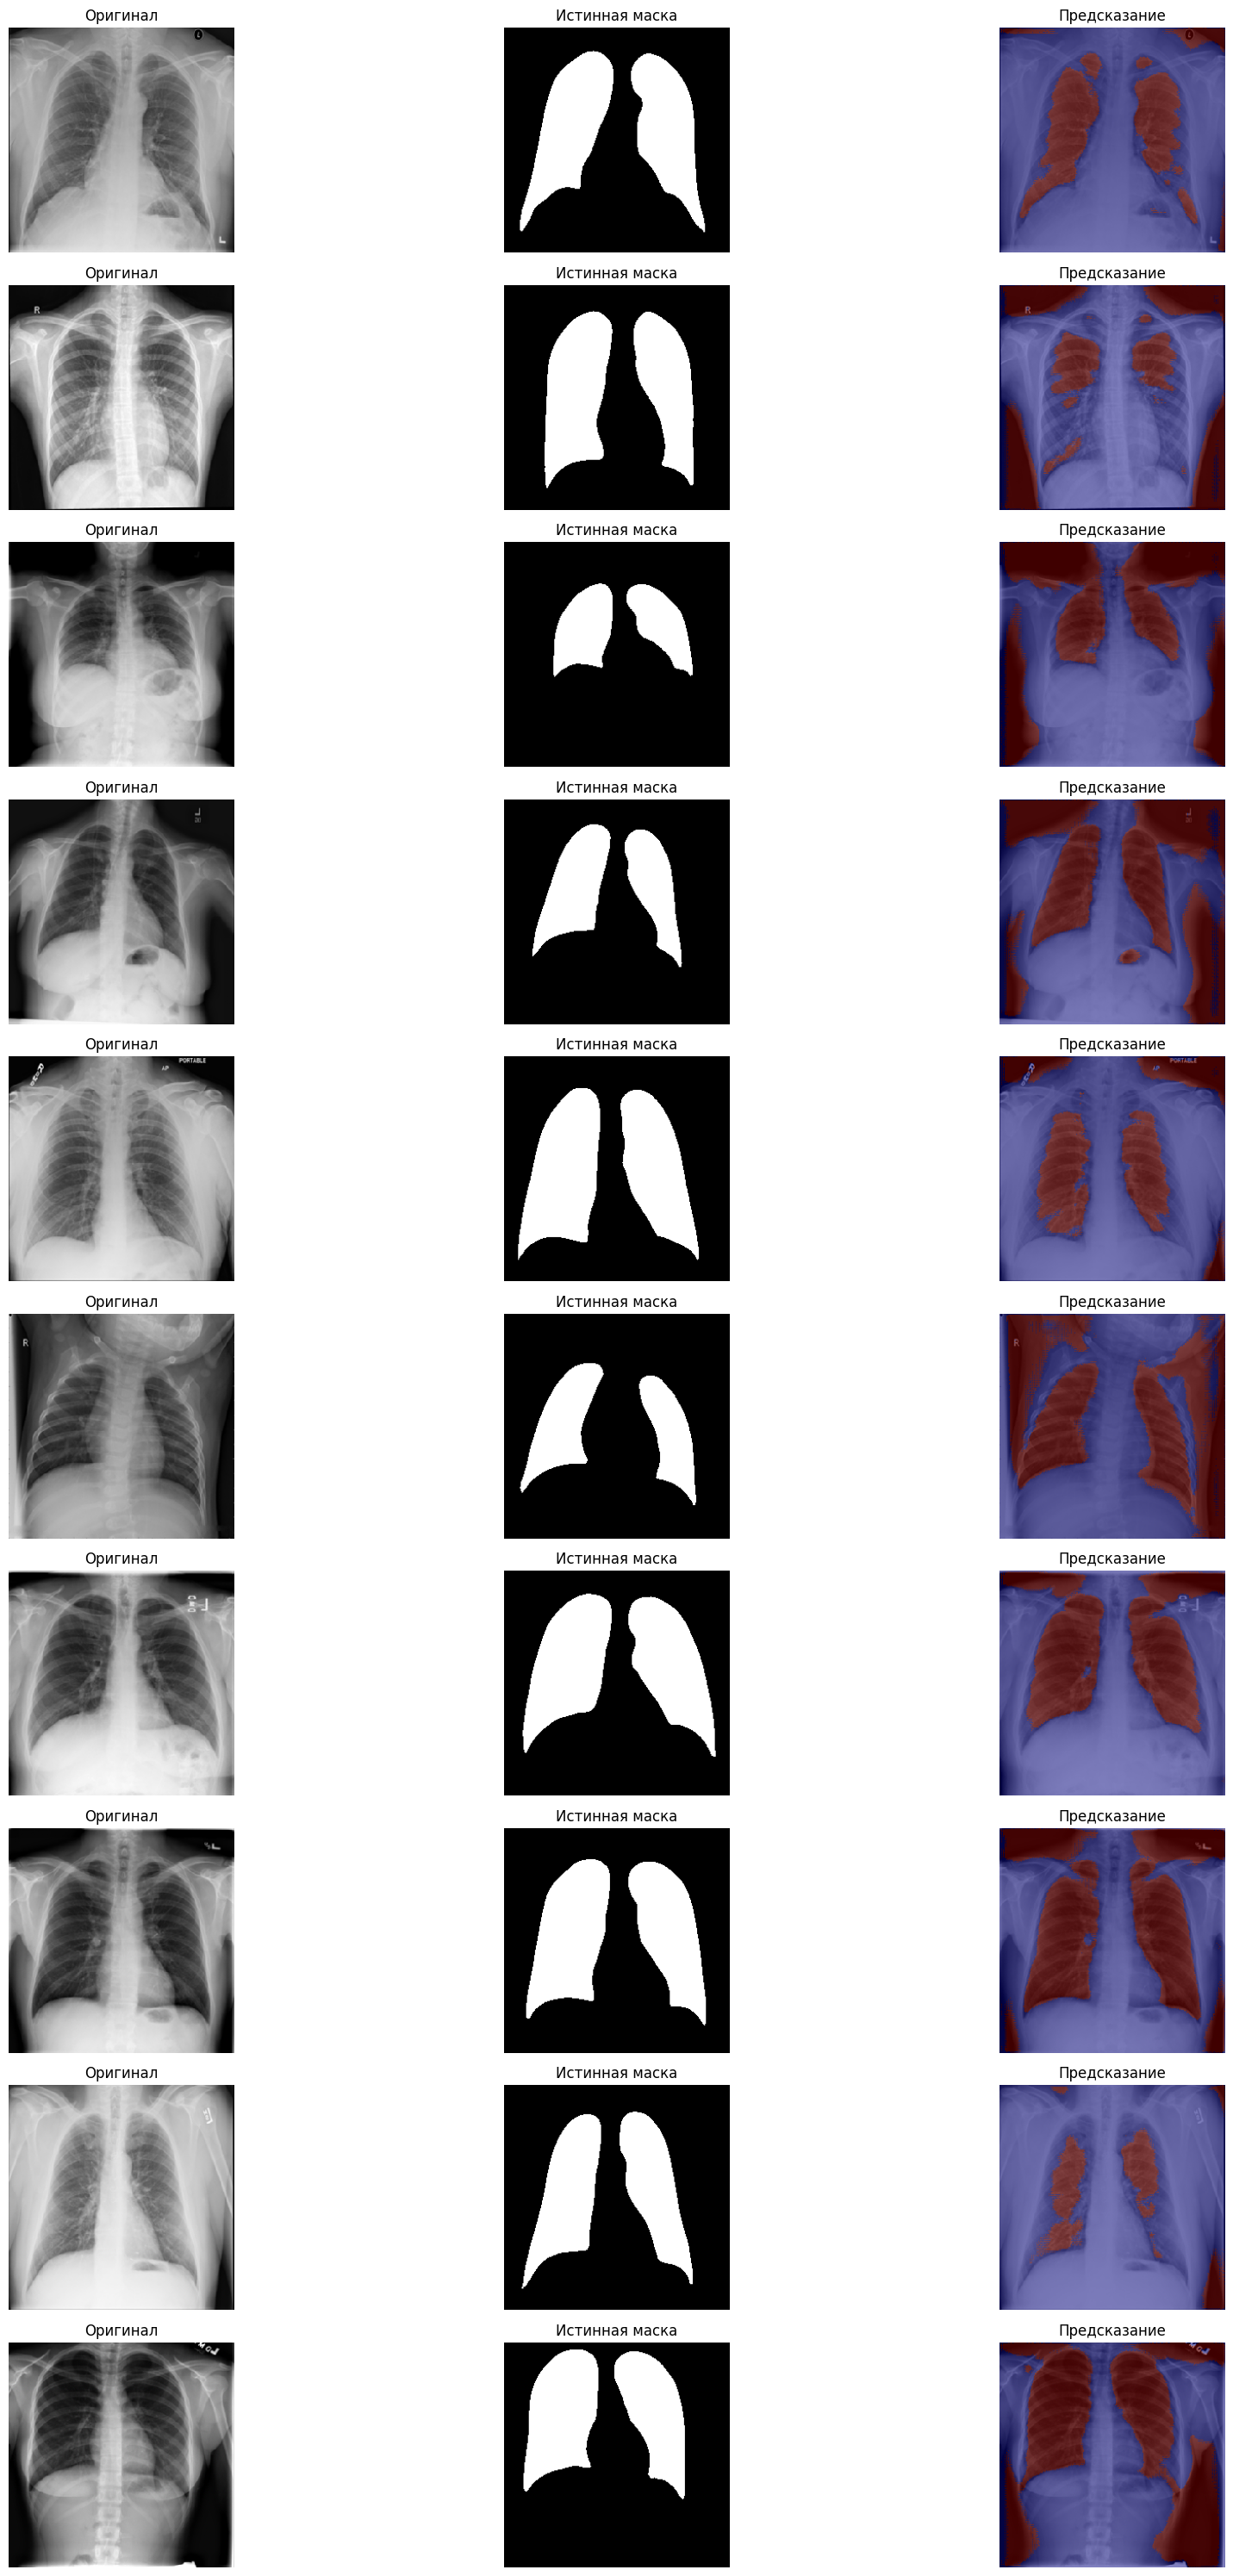

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_unetplusplus.keras')

# Берём 10 случайных индексов из валидационной выборки
import random
val_indices = random.sample(range(len(val_images)), 10)

plt.figure(figsize=(20, 30))
for i, idx in enumerate(val_indices):
    img_path = val_images[idx]
    mask_path = val_masks[idx]

    # Загружаем оригинал и маску
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    img = img_to_array(img) / 255.0
    mask = load_img(mask_path, target_size=IMG_SIZE, color_mode='grayscale')
    mask = img_to_array(mask) / 255.0

    # Предсказание
    pred = best_model.predict(np.expand_dims(img, 0), verbose=0)[0, :, :, 0]
    pred_bin = (pred > 0.5).astype(np.float32)

    # Отображение
    plt.subplot(10, 3, i*3 + 1)
    plt.imshow(img)
    plt.title('Оригинал')
    plt.axis('off')

    plt.subplot(10, 3, i*3 + 2)
    plt.imshow(mask[:,:,0], cmap='gray')
    plt.title('Истинная маска')
    plt.axis('off')

    plt.subplot(10, 3, i*3 + 3)
    plt.imshow(img)
    plt.imshow(pred_bin, cmap='jet', alpha=0.5)
    plt.title('Предсказание')
    plt.axis('off')

plt.tight_layout()
plt.show()

#Иготи

В результате можно заметить, что модель сегментирет легкие на снимке, пусть и с небольшими ошибками. Главная и тяжелая проблема в том, что во время обучения происходит взрыв градиента, от которого не получилось избавиться, хоть я и использовал много разных способов. Но я думаю, что этот опыт не будет лишним, так как я уснал новый термин и что такое может произойти!